# Preprocess of Kandy

In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

## Import Data

### 2019 - 2021

In [186]:
df1 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - From 2019 to 2021 mid (with NOx).xlsx")

### 2022 - 2023

In [187]:
df2 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - From 2022-10 Oct to 2023 End (with NOx).xlsx")

### 2024

In [188]:
df3 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - For 2024 (with NOx).xlsx")

### Combined the Dataframes

In [189]:
df_combined = pd.concat([df1,df2,df3],ignore_index=True)

#### New dataframe info

In [190]:
df_combined.shape

(35064, 19)

In [191]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  35064 non-null  datetime64[ns]
 1   Period End Time    35064 non-null  datetime64[ns]
 2   AT                 28362 non-null  float64       
 3   RH                 28356 non-null  float64       
 4   BP                 28363 non-null  float64       
 5   Solar Rad          28367 non-null  float64       
 6   Rain Gauge         28073 non-null  float64       
 7   WS Raw             27931 non-null  float64       
 8   WD Raw             28365 non-null  float64       
 9   WS Average         18027 non-null  float64       
 10  WD Average         18031 non-null  float64       
 11  O3 Conc            26782 non-null  float64       
 12  CO Conc            23788 non-null  float64       
 13  NO Conc            25946 non-null  float64       
 14  NO2 Co

In [192]:
df_combined.describe()

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,35064,35064,28362.000000,28356.000000,28363.000000,28367.000000,28073.000000,27931.000000,28365.000000,18027.000000,18031.000000,26782.000000,23788.000000,25946.000000,25905.000000,25948.000000,23659.000000,22977.000000,24091.000000
mean,2021-07-08 11:02:24.187363072,2021-07-08 12:02:24.147844096,25.861723,71.360957,954.454367,160.941920,0.178948,1.113508,196.592843,0.512215,195.797665,11.388677,652.752145,14.097119,13.030843,27.110431,1.041188,17.380859,43.971151
min,2019-01-01 00:00:00,2019-01-01 01:00:00,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.157000,-6.800000,0.000000,-1.870000,-3.780000,0.000000,0.000000
25%,2020-01-01 05:45:00,2020-01-01 06:45:00,23.200000,61.140000,953.100000,0.160000,0.000000,0.400000,162.100000,0.200000,121.450000,4.910000,455.717500,1.660000,5.900000,8.030000,0.390000,8.000000,28.000000
50%,2020-12-31 11:30:00,2020-12-31 12:30:00,25.000000,74.700000,954.400000,4.240000,0.000000,1.000000,201.200000,0.400000,208.300000,8.480000,614.900000,8.110000,11.030000,20.507500,1.040000,15.000000,40.000000
75%,2023-04-02 17:15:00,2023-04-02 18:15:00,28.300000,83.222500,955.800000,281.750000,0.000000,1.600000,227.000000,0.700000,279.400000,15.570000,790.815000,20.300000,17.280000,37.462500,1.690000,23.000000,56.000000
max,2024-12-31 23:00:00,2025-01-01 00:00:00,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,2.000000,360.000000,87.800000,9401.800000,258.450000,90.470000,348.300000,25.760000,188.000000,202.000000
std,NaN,NaN,3.396117,14.553382,1.927623,237.078795,1.418530,0.861965,40.250626,0.364607,94.126721,9.545026,338.926538,17.500552,9.642111,25.434777,1.000279,12.506621,22.575014


## Duplicates

In [193]:
df_combined.duplicated().sum()

0

No duplicates there for we don't need to do anything about it 

## Null check

In [194]:
df_combined.isnull().sum()

Period Start Time        0
Period End Time          0
AT                    6702
RH                    6708
BP                    6701
Solar Rad             6697
Rain Gauge            6991
WS Raw                7133
WD Raw                6699
WS Average           17037
WD Average           17033
O3 Conc               8282
CO Conc              11276
NO Conc               9118
NO2 Conc              9159
NOx Conc              9116
SO2 Conc             11405
PM2.5 Conc           12087
PM10 Conc            10973
dtype: int64

In here, we don't need to drop any columns. We can fill the values

<function matplotlib.pyplot.show(close=None, block=None)>

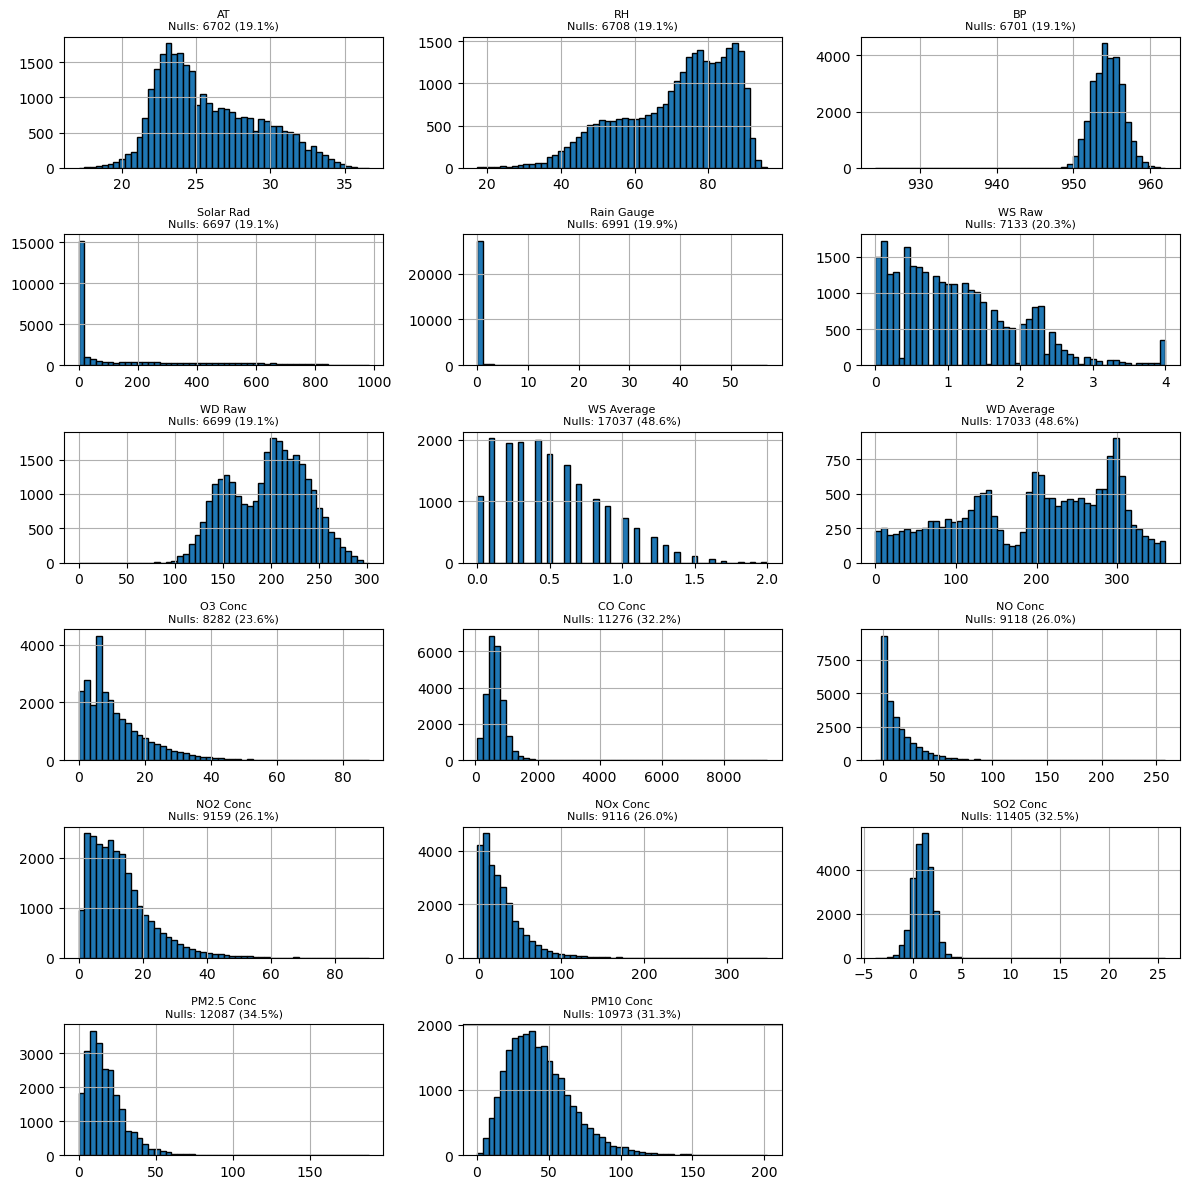

In [195]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

# Layout setup
n_cols = 3   # number of plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten()  # make it 1D for easy iteration

for i, col in enumerate(numeric_cols):
    df_combined[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

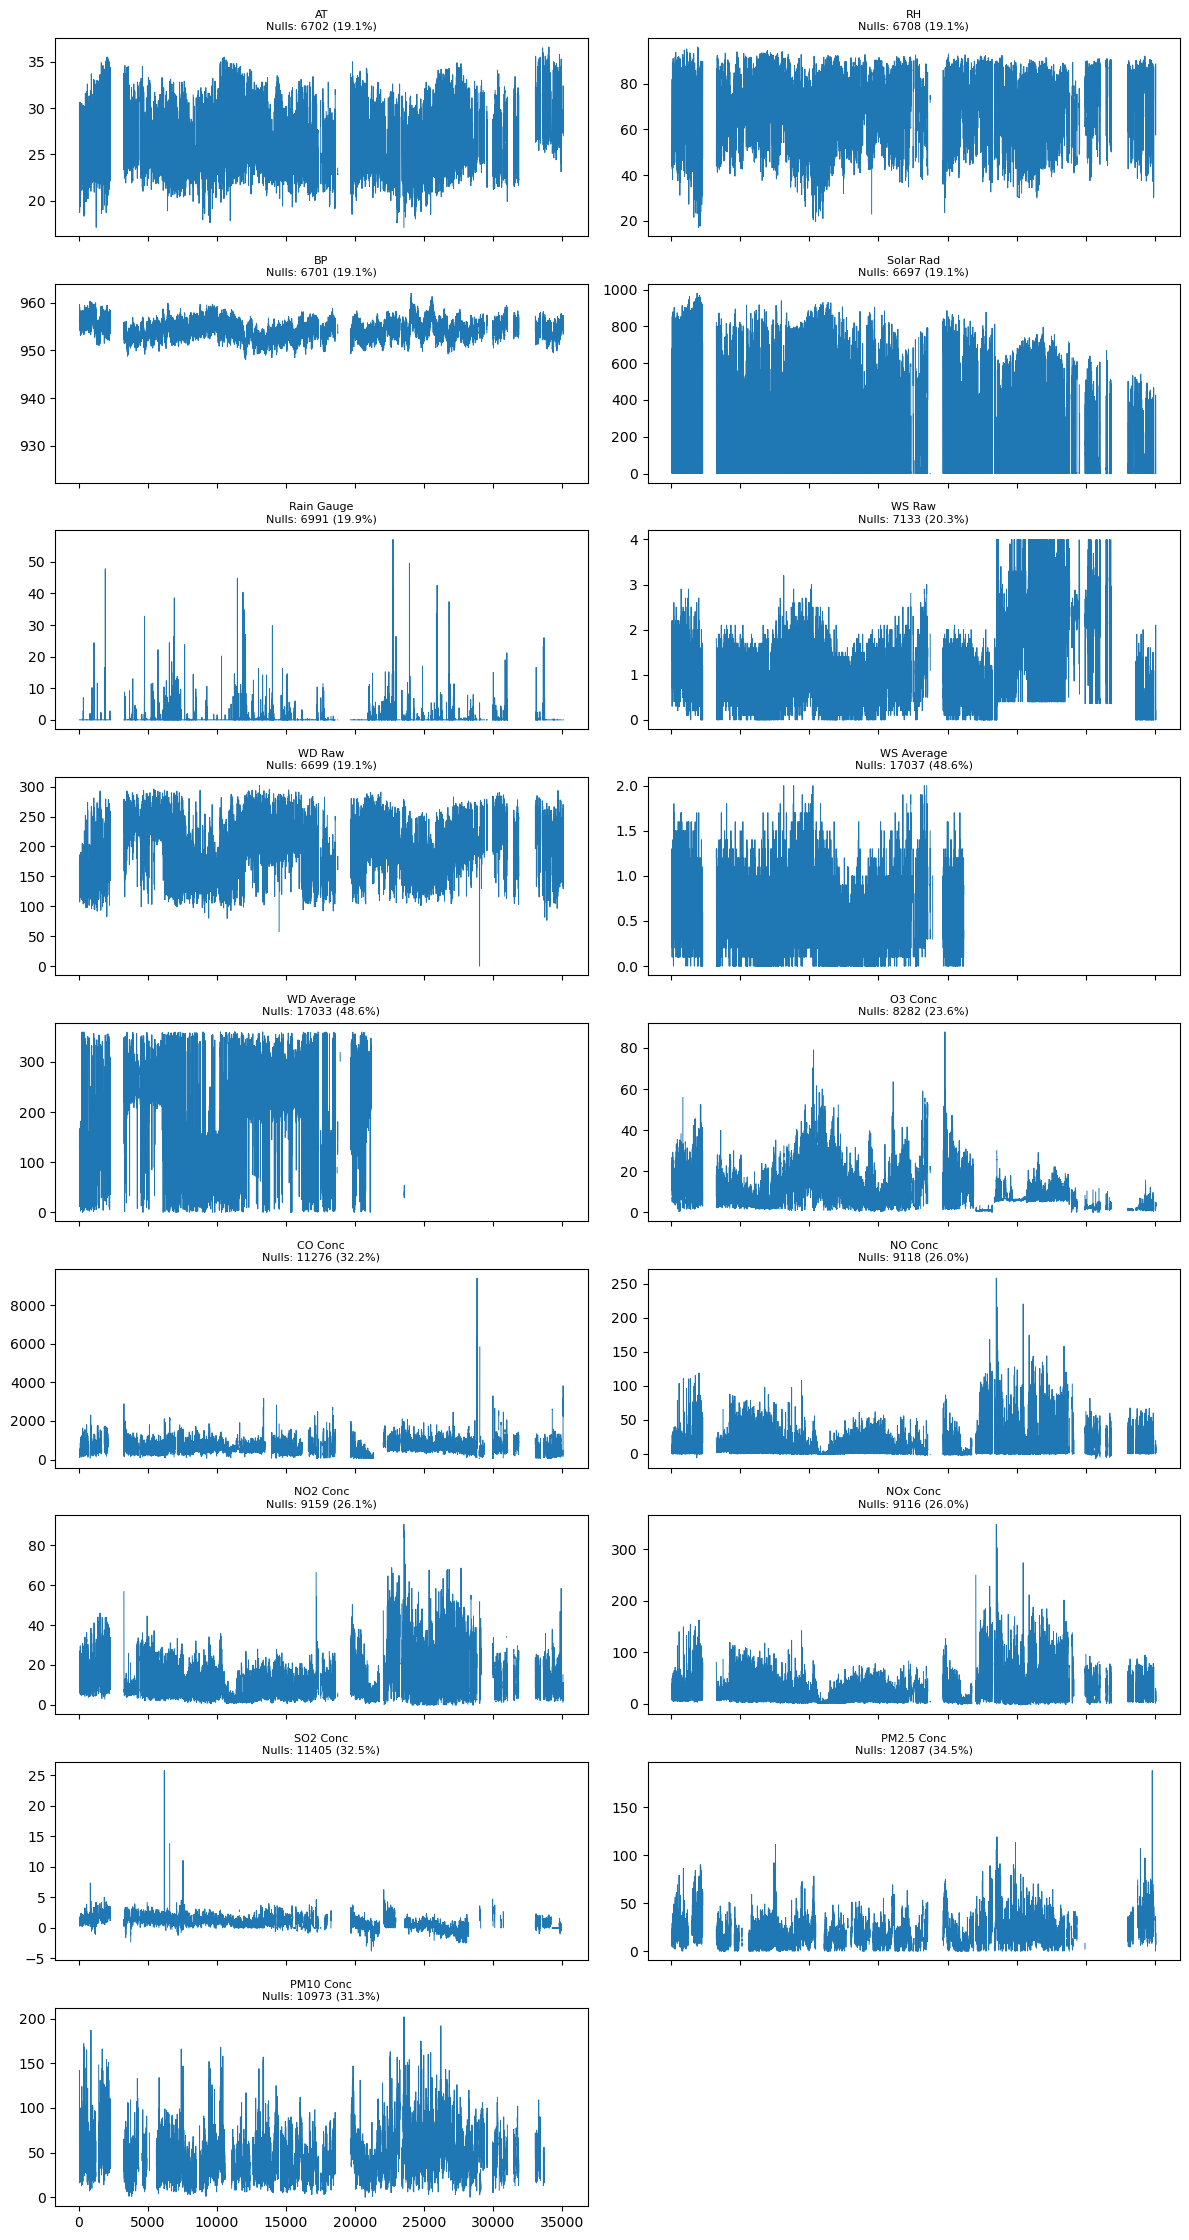

In [196]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*2.5), sharex=True)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(df_combined.index, df_combined[col], linewidth=0.7)
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

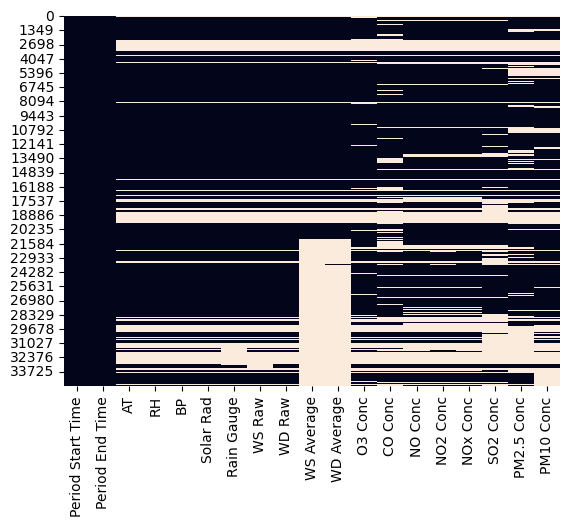

In [197]:
sns.heatmap(df_combined.isnull(), cbar=False)
plt.show()

## Conclutions

1. There is a large gap in data missing in 2021 - July to 2022 Oct. Filling this data is almost impossible. Even if we fill this, it introduces so much data. If we were to fill that data, it doesn't even have any seasonality. Instead of doing this, we should split this gap or remove that gap. We can split the data one is 2019 to 2021 June other from 2022 November to 2024. I think this is the best way to do this
2. If we do the above method, null will be reduced, then we don't need to drop those columns. I have to check before doing it

## Cheack for the all null cloumn Data Gaps

In [198]:
time_col = 'Period Start Time'
data_cols = [c for c in df_combined.columns if c != time_col and 'Time' not in c]

In [199]:
df_combined[time_col] = pd.to_datetime(df_combined[time_col])
df_combined = df_combined.sort_values(time_col).reset_index(drop=True)

In [200]:
null_mask = df_combined[data_cols].isna().all(axis=1)

In [201]:
df_combined['null_block'] = (null_mask != null_mask.shift()).cumsum()
outage_blocks = []

In [202]:
for _, block in df_combined.groupby('null_block'):
    if block[data_cols].isna().all(axis=1).any(): 
        start_time = block[time_col].iloc[0]
        end_time = block[time_col].iloc[-1]
        num_rows = len(block)
        outage_blocks.append({'Start': start_time, 'End': end_time, 'Records': num_rows})

In [203]:
outage_df = pd.DataFrame(outage_blocks)
print(outage_df)
print(f"\nTotal outage periods detected: {len(outage_df)}")

                 Start                 End  Records
0  2019-01-01 00:00:00 2019-01-03 14:00:00       63
1  2019-02-28 04:00:00 2019-02-28 04:00:00        1
2  2019-04-06 11:00:00 2019-05-17 12:00:00      986
3  2019-06-04 09:00:00 2019-06-06 15:00:00       55
4  2019-07-01 12:00:00 2019-07-05 09:00:00       94
..                 ...                 ...      ...
73 2023-11-19 21:00:00 2024-10-08 15:00:00     1195
74 2024-10-24 12:00:00 2024-10-29 15:00:00      124
75 2024-11-08 12:00:00 2024-11-10 13:00:00       50
76 2024-11-25 12:00:00 2024-11-28 12:00:00       73
77 2024-12-26 04:00:00 2024-12-30 17:00:00      110

[78 rows x 3 columns]

Total outage periods detected: 78


In [204]:
outage_df[outage_df['Records'] < 100]

,Start,End,Records
0,2019-01-01 00:00:00,2019-01-03 14:00:00,63
1,2019-02-28 04:00:00,2019-02-28 04:00:00,1
3,2019-06-04 09:00:00,2019-06-06 15:00:00,55
4,2019-07-01 12:00:00,2019-07-05 09:00:00,94
5,2019-12-07 21:00:00,2019-12-07 21:00:00,1
...,...,...,...
69,2023-11-07 01:00:00,2023-11-07 01:00:00,1
71,2023-11-15 16:00:00,2023-11-15 16:00:00,1
72,2023-11-18 17:00:00,2023-11-18 17:00:00,1
75,2024-11-08 12:00:00,2024-11-10 13:00:00,50


In [205]:
outage_df[outage_df['Records'] > 100]

,Start,End,Records
2,2019-04-06 11:00:00,2019-05-17 12:00:00,986
16,2020-12-24 10:00:00,2020-12-30 07:00:00,142
29,2021-02-12 17:00:00,2021-02-18 07:00:00,135
32,2021-02-20 05:00:00,2021-02-27 11:00:00,175
33,2021-02-27 14:00:00,2021-03-30 09:00:00,740
35,2022-11-26 11:00:00,2022-12-02 09:00:00,143
40,2023-07-17 15:00:00,2023-07-22 13:00:00,119
43,2023-08-08 13:00:00,2023-08-14 17:00:00,149
46,2023-08-16 10:00:00,2023-09-01 09:00:00,384
65,2023-10-17 04:00:00,2023-11-03 16:00:00,421


Let's remove all the data gaps that have more than 100 records (4 days)

In [206]:
for _, row in outage_df[outage_df['Records'] > 100].iterrows():
    start, end = row['Start'], row['End']
    df_combined = df_combined[~((df_combined['Period Start Time'] >= start) & (df_combined['Period Start Time'] <= end))]

In [207]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30129 entries, 0 to 35063
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30129 non-null  datetime64[ns]
 1   Period End Time    30129 non-null  datetime64[ns]
 2   AT                 28362 non-null  float64       
 3   RH                 28356 non-null  float64       
 4   BP                 28363 non-null  float64       
 5   Solar Rad          28367 non-null  float64       
 6   Rain Gauge         28073 non-null  float64       
 7   WS Raw             27931 non-null  float64       
 8   WD Raw             28365 non-null  float64       
 9   WS Average         18027 non-null  float64       
 10  WD Average         18031 non-null  float64       
 11  O3 Conc            26782 non-null  float64       
 12  CO Conc            23788 non-null  float64       
 13  NO Conc            25946 non-null  float64       
 14  NO2 Conc   

In [208]:
df_combined.describe()

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc,null_block
count,30129,30129,28362.000000,28356.000000,28363.000000,28367.000000,28073.000000,27931.000000,28365.000000,18027.000000,18031.000000,26782.000000,23788.000000,25946.000000,25905.000000,25948.000000,23659.000000,22977.000000,24091.000000,30129.000000
mean,2021-05-20 10:36:24.492870656,2021-05-20 11:36:24.446878464,25.861723,71.360957,954.454367,160.941920,0.178948,1.113508,196.592843,0.512215,195.797665,11.388677,652.752145,14.097119,13.030843,27.110431,1.041188,17.380859,43.971151,45.680042
min,2019-01-01 00:00:00,2019-01-01 01:00:00,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.157000,-6.800000,0.000000,-1.870000,-3.780000,0.000000,0.000000,1.000000
25%,2019-12-21 22:00:00,2019-12-21 23:00:00,23.200000,61.140000,953.100000,0.160000,0.000000,0.400000,162.100000,0.200000,121.450000,4.910000,455.717500,1.660000,5.900000,8.030000,0.390000,8.000000,28.000000,14.000000
50%,2020-10-30 18:00:00,2020-10-30 19:00:00,25.000000,74.700000,954.400000,4.240000,0.000000,1.000000,201.200000,0.400000,208.300000,8.480000,614.900000,8.110000,11.030000,20.507500,1.040000,15.000000,40.000000,20.000000
75%,2023-02-04 05:00:00,2023-02-04 06:00:00,28.300000,83.222500,955.800000,281.750000,0.000000,1.600000,227.000000,0.700000,279.400000,15.570000,790.815000,20.300000,17.280000,37.462500,1.690000,23.000000,56.000000,74.000000
max,2024-12-31 23:00:00,2025-01-01 00:00:00,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,2.000000,360.000000,87.800000,9401.800000,258.450000,90.470000,348.300000,25.760000,188.000000,202.000000,156.000000
std,NaN,NaN,3.396117,14.553382,1.927623,237.078795,1.418530,0.861965,40.250626,0.364607,94.126721,9.545026,338.926538,17.500552,9.642111,25.434777,1.000279,12.506621,22.575014,41.896002


<function matplotlib.pyplot.show(close=None, block=None)>

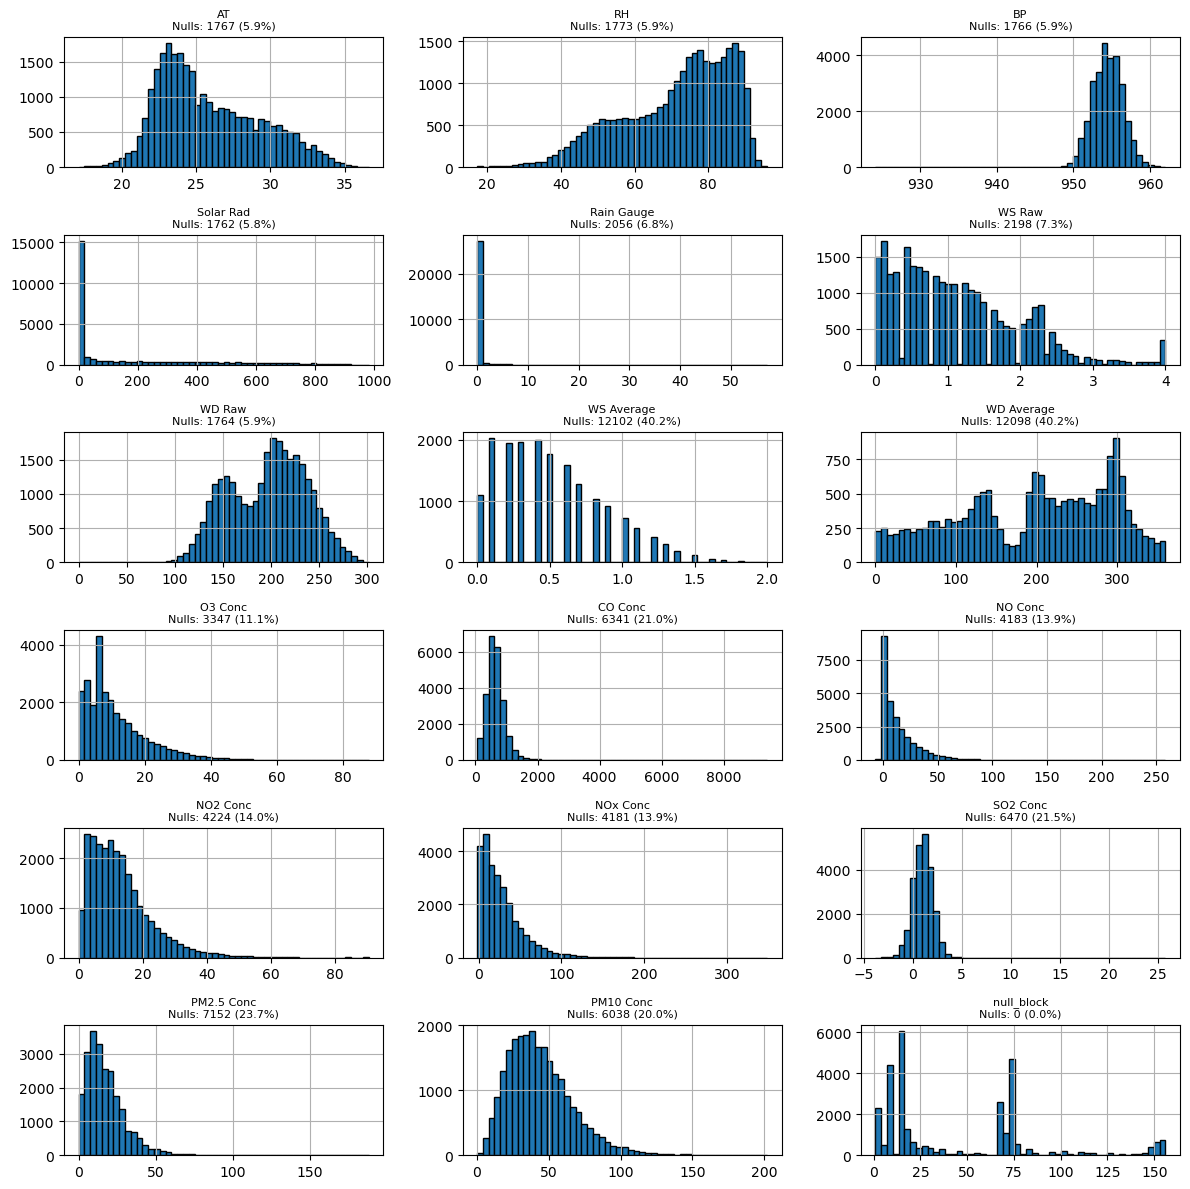

In [209]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_combined[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

1. We don't need WS Average & WD Average because WS Raw & WD Raw columns are showing the same thing.

There is a large gap of the data missing showing on the belows graph. It is not actual data missing it happened because we removed the large gap from 2021-07 to 2022-10. So what this graph does is continue the time correctly but there is no data in that period. It connects the last data point with a line

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23596\3663450081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_time['Date'] = df_o3_time['Period Start Time'].dt.date


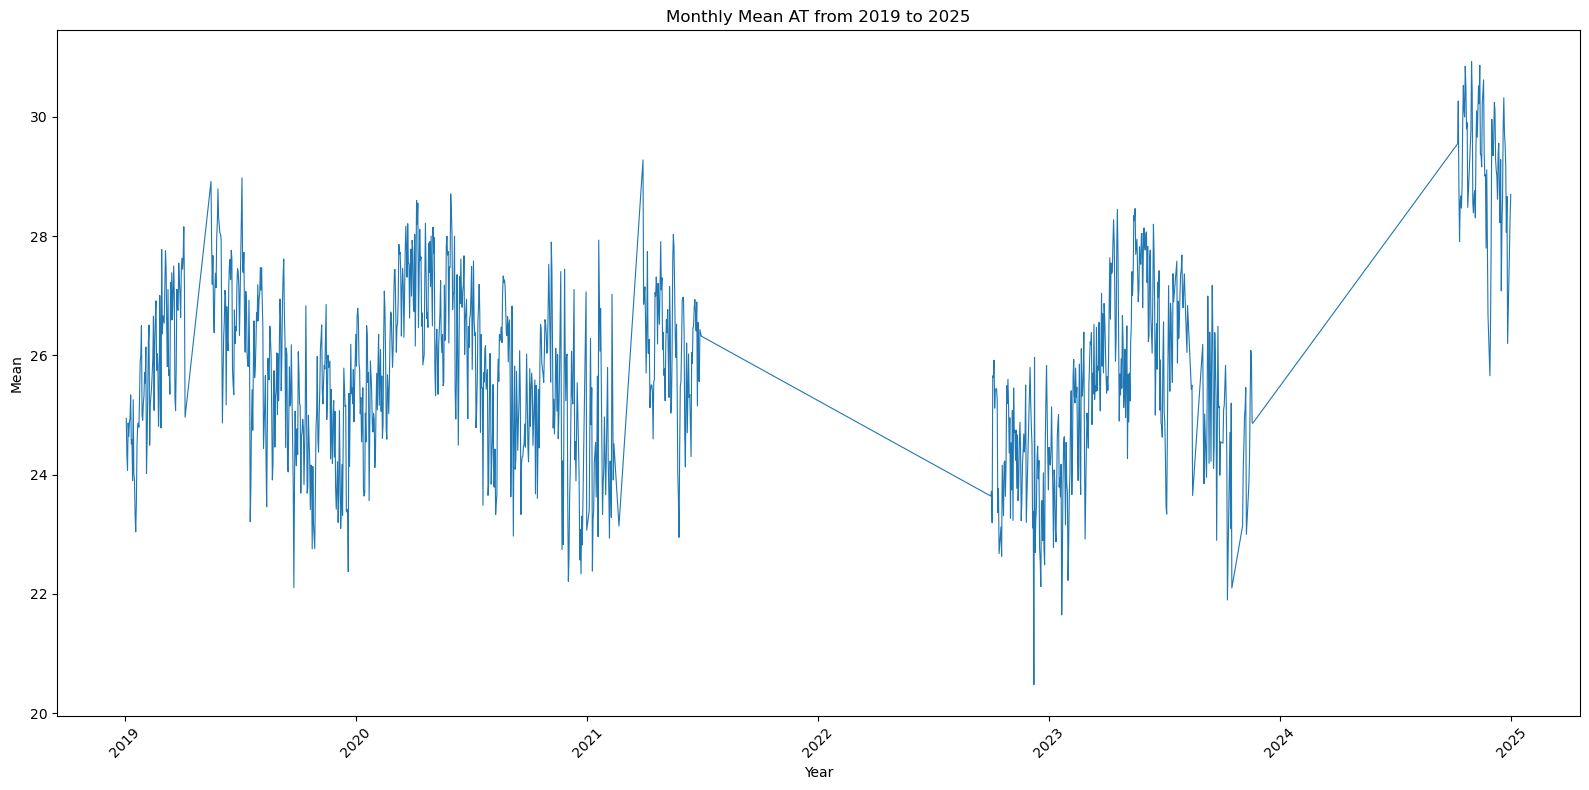

In [210]:
df_o3_time = df_combined[['Period Start Time','AT']]

df_o3_time['Date'] = df_o3_time['Period Start Time'].dt.date

df_filtered = df_o3_time[(df_o3_time['Period Start Time'].dt.year >= 2019) &
                         (df_o3_time['Period Start Time'].dt.year <= 2024)]

daily_at = df_filtered.groupby('Date')['AT'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(x='Date', y='AT', data=daily_at, linewidth=0.8)
plt.title('Monthly Mean AT from 2019 to 2025')
plt.xlabel('Year')
plt.ylabel('Mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dropping the large null value columns

We don't need to drop any column in here apart from some useless columns to drop
- WS Average
- WD Average
 * Also the null block column we don't need that anymore
 * We don't need Period End Time we can see that time stamp using Period Start Time

In [211]:
df_combined2 = df_combined.drop([ 'WS Average', 'WD Average', 'null_block', 'Period End Time'], axis=1)

In [212]:
df_combined3 = df_combined2.reset_index(drop=True)
df_combined3

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
0,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30124,2024-12-31 19:00:00,27.9,80.8,955.6,0.1,0.0,0.5,178.2,3.96,2823.0,5.162,7.413,12.576,NaN,13.0,NaN
30125,2024-12-31 20:00:00,27.4,84.8,956.0,0.1,0.0,0.1,240.7,2.54,3000.1,10.521,10.870,21.386,NaN,16.0,NaN
30126,2024-12-31 21:00:00,27.3,85.7,956.9,0.1,0.0,0.1,264.0,2.90,2727.4,7.410,6.929,14.336,NaN,19.0,NaN
30127,2024-12-31 22:00:00,27.2,87.5,957.0,0.1,0.0,0.0,200.0,3.35,2532.0,4.460,6.030,10.489,NaN,10.0,NaN


In [213]:
df_combined3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30129 entries, 0 to 30128
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30129 non-null  datetime64[ns]
 1   AT                 28362 non-null  float64       
 2   RH                 28356 non-null  float64       
 3   BP                 28363 non-null  float64       
 4   Solar Rad          28367 non-null  float64       
 5   Rain Gauge         28073 non-null  float64       
 6   WS Raw             27931 non-null  float64       
 7   WD Raw             28365 non-null  float64       
 8   O3 Conc            26782 non-null  float64       
 9   CO Conc            23788 non-null  float64       
 10  NO Conc            25946 non-null  float64       
 11  NO2 Conc           25905 non-null  float64       
 12  NOx Conc           25948 non-null  float64       
 13  SO2 Conc           23659 non-null  float64       
 14  PM2.5 

### Null Map

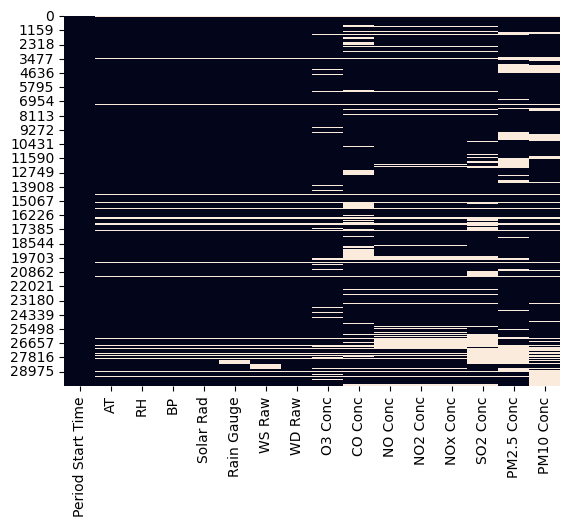

In [214]:
sns.heatmap(df_combined3.isnull(), cbar=False)
plt.show()

### Correlation heatmap

In [215]:
corr_columns = ['AT', 'RH', 'BP', 'Solar Rad',
       'Rain Gauge', 'WD Raw', 'O3 Conc', 'NO Conc', 'NO2 Conc',
       'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
corr_df = df_combined3[corr_columns]

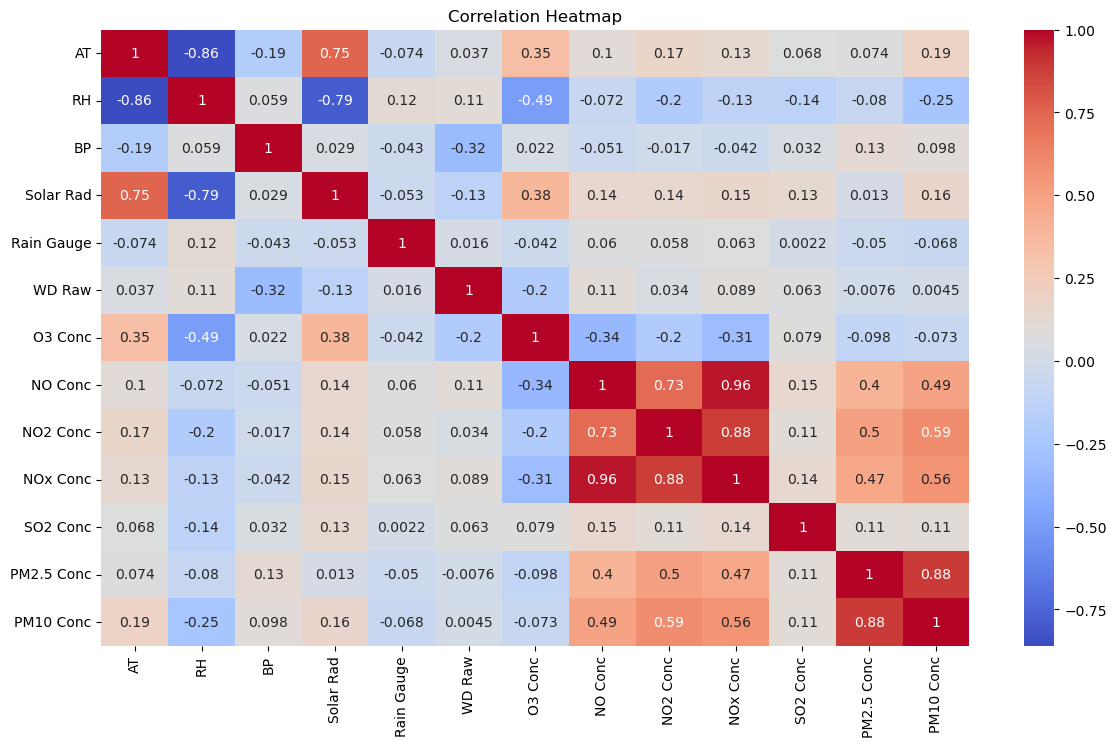

In [216]:
corr = corr_df.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Null threatment

### Fowardfill Method

* Fill the small gaps with time forward fill.
* This is only possible because usually data (pollutant and weather) do not change within the same close hours. Likely the same as the hour before.
* There for we can fill the small gap with 3 hour limit.

In [217]:
df_filled = df_combined3.ffill(limit=3)

In [218]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30129 entries, 0 to 30128
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30129 non-null  datetime64[ns]
 1   AT                 28527 non-null  float64       
 2   RH                 28531 non-null  float64       
 3   BP                 28531 non-null  float64       
 4   Solar Rad          28531 non-null  float64       
 5   Rain Gauge         28234 non-null  float64       
 6   WS Raw             28098 non-null  float64       
 7   WD Raw             28531 non-null  float64       
 8   O3 Conc            28130 non-null  float64       
 9   CO Conc            25222 non-null  float64       
 10  NO Conc            27313 non-null  float64       
 11  NO2 Conc           27289 non-null  float64       
 12  NOx Conc           27314 non-null  float64       
 13  SO2 Conc           24815 non-null  float64       
 14  PM2.5 

<function matplotlib.pyplot.show(close=None, block=None)>

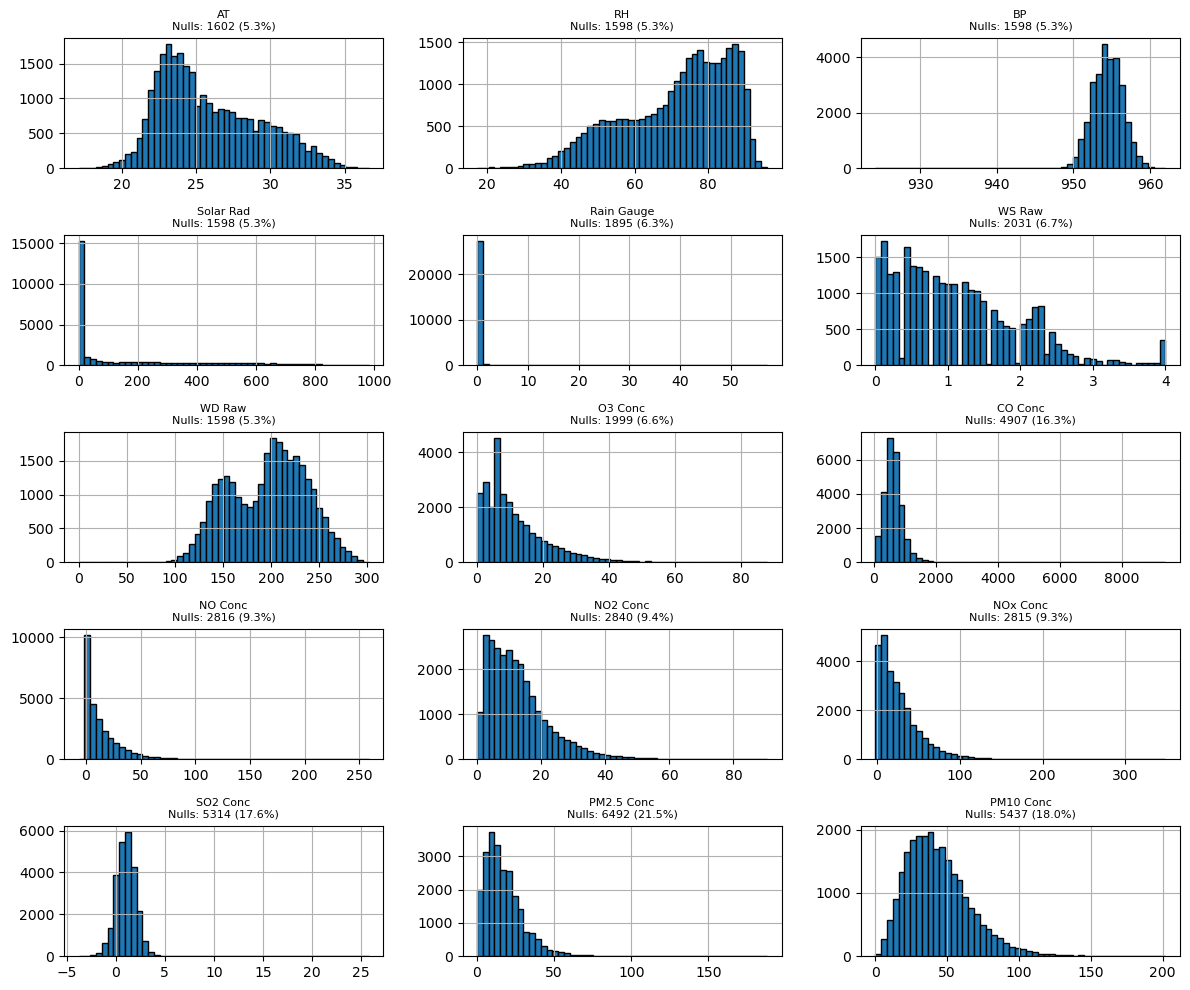

In [219]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

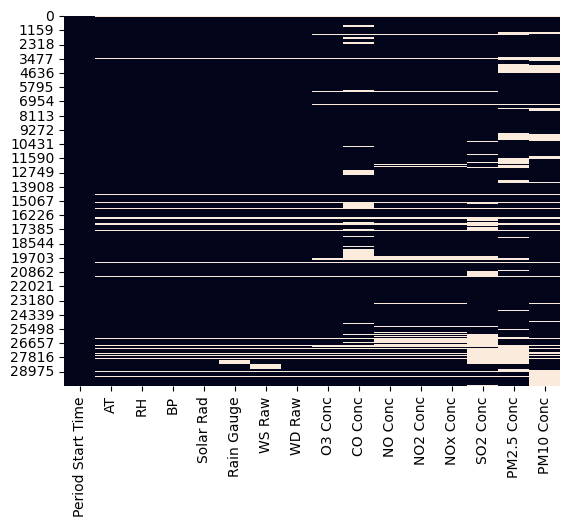

In [220]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

### Interpolate using Time

After filling the tiny gaps, we still have larger ones. For many of your variables, a simple time-based interpolation is the best way to fill them.

* Method: Linear or Time Interpolation

* Why: It assumes a smooth, gradual change between two known points (e.g., the temperature didn't teleport; it rose or fell steadily). This is a very strong assumption for environmental data.

In [221]:
if df_filled.index.name != 'Period Start Time':
    df_filled = df_filled.set_index('Period Start Time')

In [222]:
cols_to_interpolate = ['RH', 'BP', 'Solar Rad', 'Rain Gauge', 'WD Raw', 'WS Raw']
df_filled[cols_to_interpolate] = df_filled[cols_to_interpolate].interpolate(method='time')

In [223]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30129 entries, 2019-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AT          28527 non-null  float64
 1   RH          30066 non-null  float64
 2   BP          30066 non-null  float64
 3   Solar Rad   30066 non-null  float64
 4   Rain Gauge  30066 non-null  float64
 5   WS Raw      30066 non-null  float64
 6   WD Raw      30066 non-null  float64
 7   O3 Conc     28130 non-null  float64
 8   CO Conc     25222 non-null  float64
 9   NO Conc     27313 non-null  float64
 10  NO2 Conc    27289 non-null  float64
 11  NOx Conc    27314 non-null  float64
 12  SO2 Conc    24815 non-null  float64
 13  PM2.5 Conc  23637 non-null  float64
 14  PM10 Conc   24692 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [224]:
df_filled

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
Period Start Time,,,,,,,,,,,,,,,
2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,27.9,80.8,955.6,0.1,0.0,0.5,178.2,3.96,2823.0,5.162,7.413,12.576,NaN,13.0,NaN
2024-12-31 20:00:00,27.4,84.8,956.0,0.1,0.0,0.1,240.7,2.54,3000.1,10.521,10.870,21.386,NaN,16.0,NaN
2024-12-31 21:00:00,27.3,85.7,956.9,0.1,0.0,0.1,264.0,2.90,2727.4,7.410,6.929,14.336,NaN,19.0,NaN


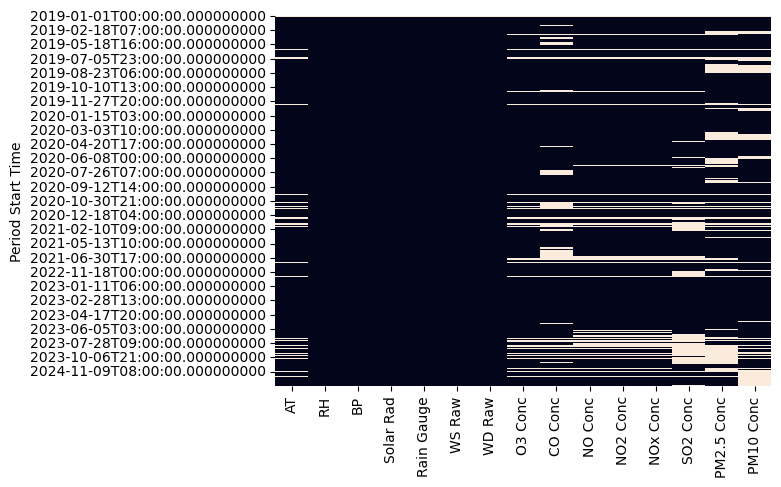

In [225]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

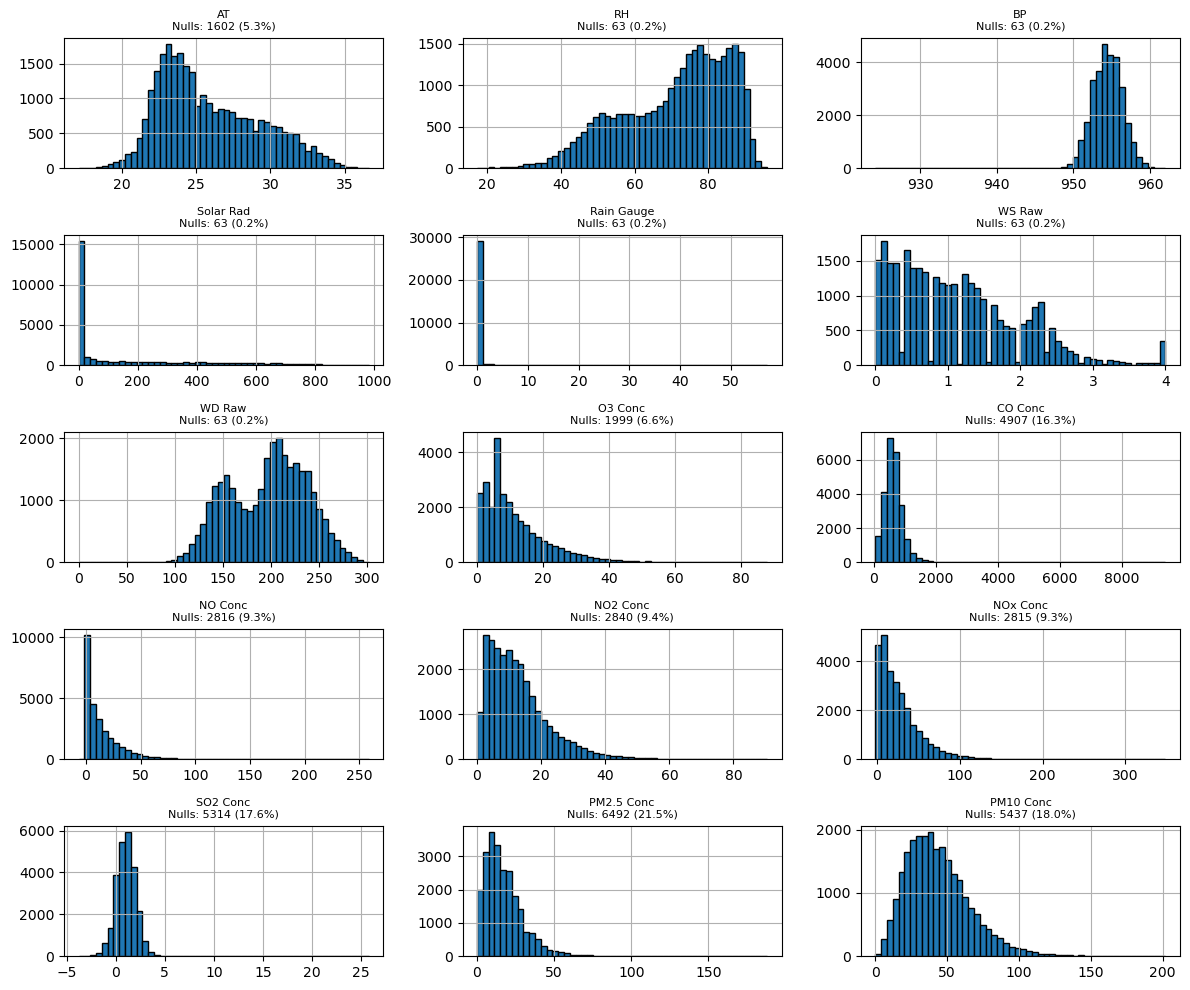

In [226]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

### Multivariate Imputation (MICE)

* These are the columns that have large missing blocks (AT, O3, PM2.5, PM10) or are highly correlated with that block (Solar Rad, NO, NO2, NOx, SO2).
* We will use IterativeImputer (MICE) to build a model that uses all these columns to predict and fill the gaps in each other. This will capture the complex relationships shown in the heatmap (like AT vs. RH, PM2.5 vs. PM10, and O3 vs. Solar Rad)
- Also this one could be a novel thing

In [227]:
complex_cols = [
    'AT',
    'Solar Rad',
    'O3 Conc',
    'CO Conc',
    'NO Conc',
    'NO2 Conc',
    'NOx Conc',
    'SO2 Conc',
    'PM2.5 Conc',
    'PM10 Conc'
]

In [228]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=0)
df_filled[complex_cols] = imputer.fit_transform(df_filled[complex_cols])

In [229]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30129 entries, 2019-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AT          30129 non-null  float64
 1   RH          30066 non-null  float64
 2   BP          30066 non-null  float64
 3   Solar Rad   30129 non-null  float64
 4   Rain Gauge  30066 non-null  float64
 5   WS Raw      30066 non-null  float64
 6   WD Raw      30066 non-null  float64
 7   O3 Conc     30129 non-null  float64
 8   CO Conc     30129 non-null  float64
 9   NO Conc     30129 non-null  float64
 10  NO2 Conc    30129 non-null  float64
 11  NOx Conc    30129 non-null  float64
 12  SO2 Conc    30129 non-null  float64
 13  PM2.5 Conc  30129 non-null  float64
 14  PM10 Conc   30129 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [230]:
df_filled.isnull().sum()

AT             0
RH            63
BP            63
Solar Rad      0
Rain Gauge    63
WS Raw        63
WD Raw        63
O3 Conc        0
CO Conc        0
NO Conc        0
NO2 Conc       0
NOx Conc       0
SO2 Conc       0
PM2.5 Conc     0
PM10 Conc      0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

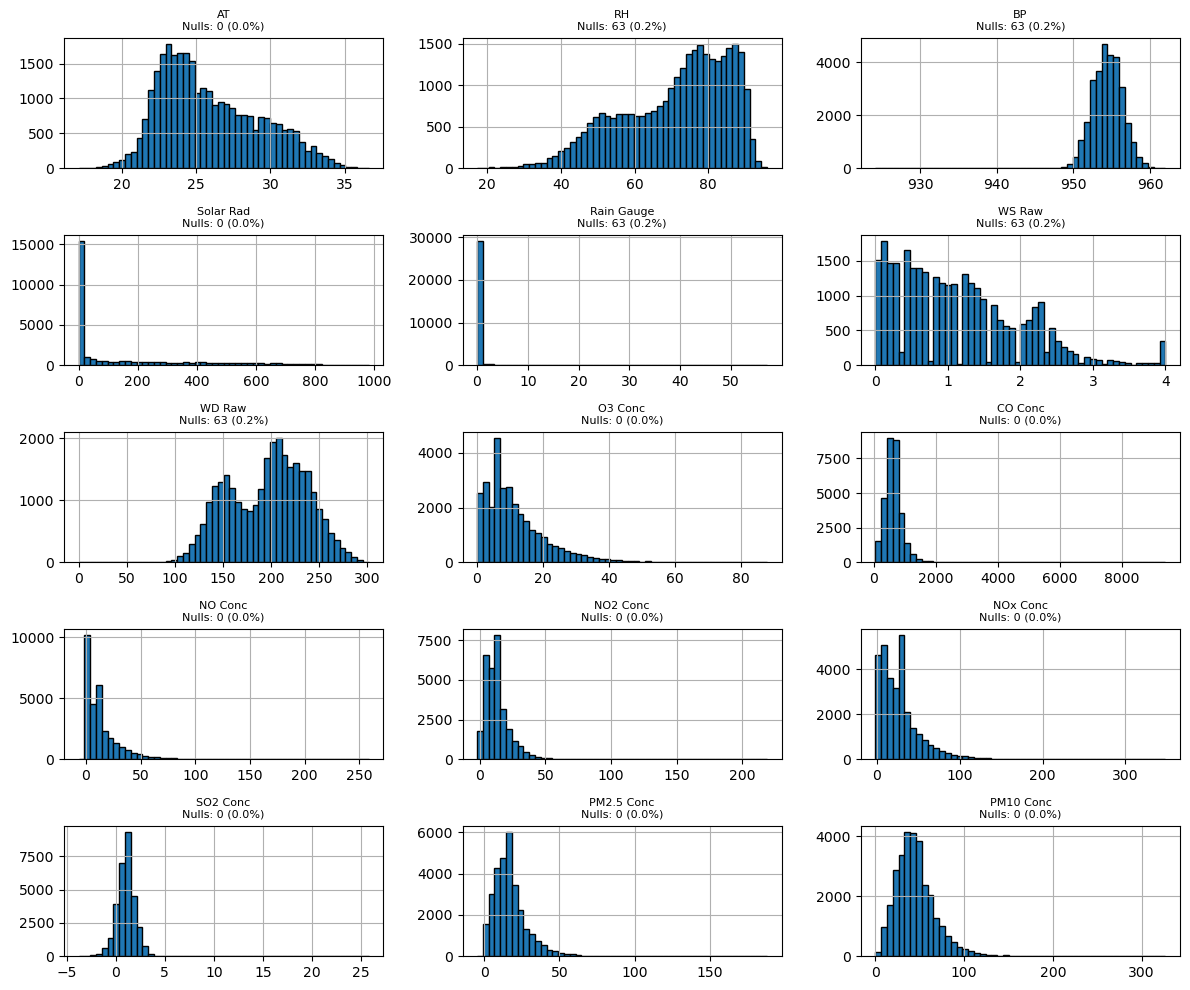

In [231]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

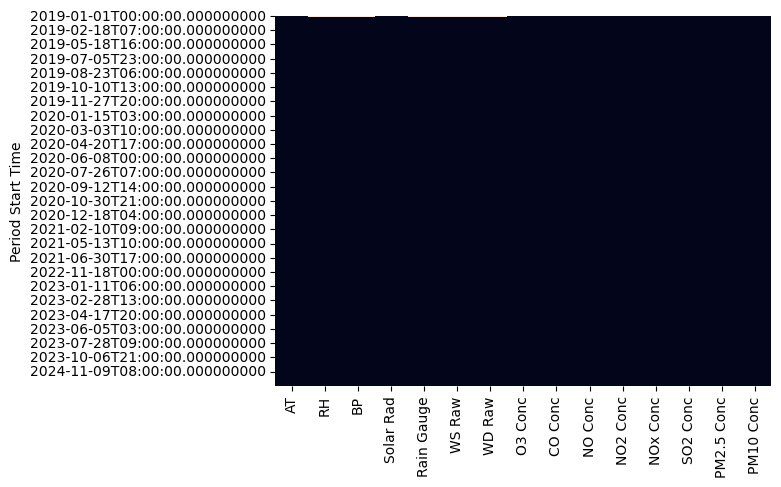

In [232]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

In [233]:
df_filled.describe()

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,30129.000000,30066.000000,30066.000000,30129.000000,30066.000000,30066.000000,30066.000000,30129.000000,30129.000000,30129.000000,30129.000000,30129.000000,30129.000000,30129.000000,30129.000000
mean,25.914471,71.068267,954.421903,166.024542,0.178344,1.128151,196.551538,11.424322,634.635220,13.890840,12.850895,26.735201,1.028308,17.043506,45.010178
std,3.351111,14.491929,1.979029,236.561605,1.378504,0.863256,40.296904,9.246661,320.330630,16.730285,9.272170,24.334007,0.918874,11.453716,21.960278
min,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.000000,50.157000,-6.800000,-2.113234,-1.870000,-3.780000,-4.812954,0.000000
25%,23.300000,60.500000,953.100000,0.160000,0.000000,0.400000,161.600000,5.310000,454.770000,1.843000,6.160000,8.550000,0.520000,9.000000,30.000000
50%,25.198129,74.340000,954.400000,14.430000,0.000000,1.000000,201.500000,8.970000,609.992404,9.510000,11.950000,22.820000,1.020000,16.000000,43.000000
75%,28.300000,82.880000,955.700000,290.970000,0.000000,1.700000,227.300000,15.400000,756.140000,18.118000,16.260000,34.870000,1.550000,22.000000,56.000000
max,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,87.800000,9401.800000,258.450000,219.002404,348.300000,25.760000,188.000000,326.936052


In [234]:
corr_columns = ['AT', 'RH', 'BP', 'Solar Rad',
       'Rain Gauge', 'WD Raw', 'O3 Conc', 'NO Conc', 'NO2 Conc',
       'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
corr_df = df_filled[corr_columns]

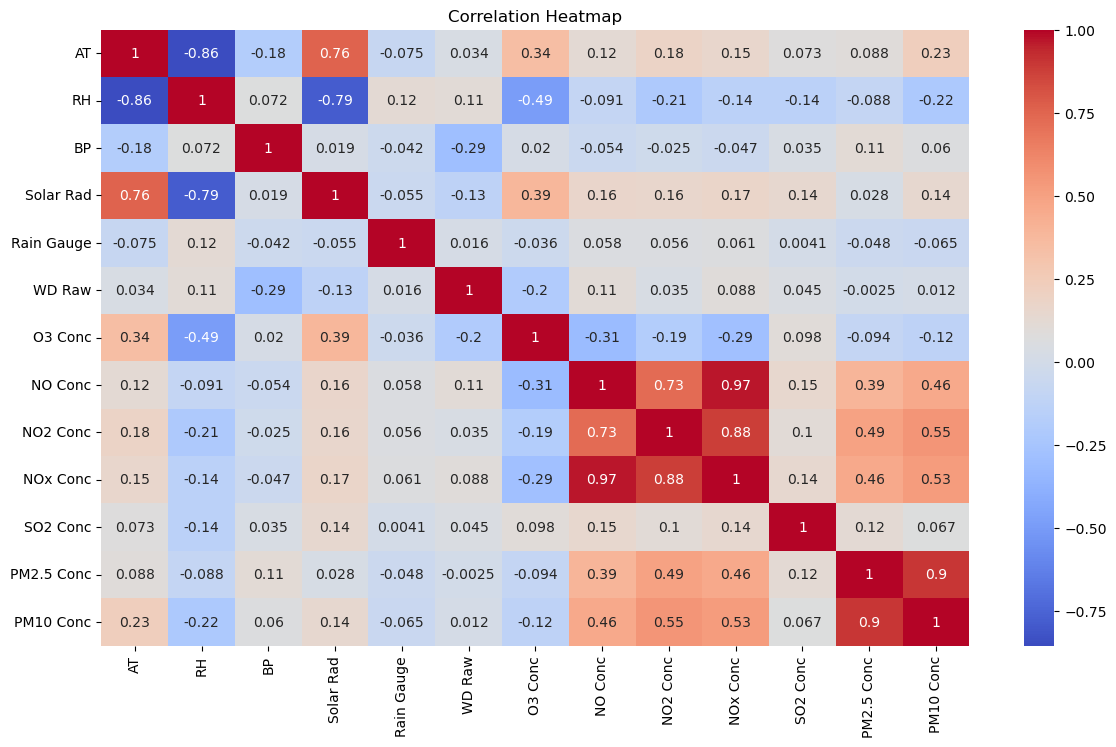

In [235]:
corr = corr_df.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [236]:
df_filled.to_csv("Kandy_data_cleaned.csv")